In [1]:
import bioframe as bf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import bbi

In [2]:
annot_gtf = pd.read_csv('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/Mus_musculus_GTF_genes_short_GRCm38_95.csv')

In [46]:
# derived from featurecounts.cpm.gene.mean.tsv
# removed duplicates and 0s manually

RNA_FeatureCounts_mean_c = pd.read_excel('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/RNA_analysis_files/RNA_FeatureCounts_mean_no0_c.xlsx')


In [6]:
RNA_FeatureCounts_mean_c[['gene_id', 'gene_name']] = RNA_FeatureCounts_mean_c['gene_id'].str.split('|', expand=True)

In [8]:
RNA_seq_annot_gi = pd.merge(RNA_FeatureCounts_mean_c, annot_gtf, how="inner", on=["gene_id", "gene_id"])


In [9]:
RNA_seq_annot = RNA_seq_annot_gi[['chrom', 'start', 'end', 'strand', 'gene_id', 'gene_name_x', 'Control', 'Experimental']]
RNA_seq_annot.columns = ['chrom', 'start', 'end', 'strand', 'gene_id', 'gene_name', 'RNA_ctr', 'RNA_exp']

In [11]:
RNA_seq_annot['gene_length'] = (RNA_seq_annot['end'] - RNA_seq_annot['start'])/1000

In [12]:
# To calculate mean TPM from mean cpm (provided as FeatureCounts output)

# Calculate average raw counts
# avg_raw_counts = avg_cpm * avg_total_assigned_reads / 1e6

# Calculate RPK
# rpkm = avg_raw_counts / gene_lengths

# Calculate scaling factor (sum of RPK)
# scaling_factor = rpkm.sum()

# Calculate TPM
# tpm = (rpkm / scaling_factor) * 1e6

In [12]:
#Average raw counts
#avg_raw_counts = avg_cpm * avg_total_assigned_reads / 1e6
RNA_seq_annot['arc_ctr'] = (RNA_seq_annot['RNA_ctr'] * 25535211)/1000000
RNA_seq_annot['arc_exp'] = (RNA_seq_annot['RNA_exp'] * 27403309)/1000000

In [14]:
#RPK
#rpkm = avg_raw_counts / gene_lengths
RNA_seq_annot['rpkm_ctr'] = RNA_seq_annot['arc_ctr'] / RNA_seq_annot['gene_length']
RNA_seq_annot['rpkm_exp'] = RNA_seq_annot['arc_exp'] / RNA_seq_annot['gene_length']

In [15]:
#scaling factor
scaling_factor_ctr = RNA_seq_annot['rpkm_ctr'].sum()
scaling_factor_exp = RNA_seq_annot['rpkm_exp'].sum()

In [16]:
#TPM
RNA_seq_annot['tpm_ctr'] = (RNA_seq_annot['rpkm_ctr'] / scaling_factor_ctr) * 1000000
RNA_seq_annot['tpm_exp'] = (RNA_seq_annot['rpkm_exp'] / scaling_factor_exp) * 1000000

In [18]:
# MR = MergedReplicate 3 vs 3

bigWig_control_MR = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp_MR = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/experimental.mRp.clN.bigWig')


In [19]:
RNA_seq_annot_for_bbi = RNA_seq_annot.copy()

In [20]:
# very important!
RNA_seq_annot_for_bbi['tss_start'] = RNA_seq_annot_for_bbi.apply(lambda row: row['start'] if row['strand'] == '+' else row['end'], axis=1)

In [21]:
RNA_seq_annot_for_bbi['str_win2'] = RNA_seq_annot_for_bbi['tss_start'] - 1000
RNA_seq_annot_for_bbi['end_win2'] = RNA_seq_annot_for_bbi['tss_start'] + 1000

In [23]:
RNA_seq_annot_for_bbi['chrom'] = RNA_seq_annot_for_bbi['chrom'].str.replace('chr', '')

In [24]:
RNA_seq_annot_for_bbi = RNA_seq_annot_for_bbi[RNA_seq_annot_for_bbi['chrom'] != 'MT']
# 33037 rows

In [25]:
cov_control = bigWig_control_MR.stackup(RNA_seq_annot_for_bbi['chrom'],
                                                        RNA_seq_annot_for_bbi['str_win2'],
                                                        RNA_seq_annot_for_bbi['end_win2'],
                                                        bins=1, summary='sum').flatten()
cov_exp = bigWig_exp_MR.stackup(RNA_seq_annot_for_bbi['chrom'],
                                                        RNA_seq_annot_for_bbi['str_win2'],
                                                        RNA_seq_annot_for_bbi['end_win2'],
                                                        bins=1, summary='sum').flatten()
 

In [26]:
RNA_seq_annot_for_bbi['ATAC_control'] = cov_control.tolist()
RNA_seq_annot_for_bbi['ATAC_exp'] = cov_exp.tolist()

# To evoid 0s and NaNs

RNA_seq_annot_for_bbi['ATAC_control'] = RNA_seq_annot_for_bbi['ATAC_control'].copy() + 0.00001
RNA_seq_annot_for_bbi['ATAC_exp'] = RNA_seq_annot_for_bbi['ATAC_exp'].copy() + 0.00001

RNA_seq_annot_for_bbi['tpm_exp'] = RNA_seq_annot_for_bbi['tpm_exp'].copy() + 0.00001
RNA_seq_annot_for_bbi['tpm_ctr'] = RNA_seq_annot_for_bbi['tpm_ctr'].copy() + 0.00001

RNA_seq_annot_for_bbi['ATAC_change'] = RNA_seq_annot_for_bbi['ATAC_exp'] / RNA_seq_annot_for_bbi['ATAC_control']

RNA_seq_annot_for_bbi['RNA_change'] = RNA_seq_annot_for_bbi['tpm_exp'] / RNA_seq_annot_for_bbi['tpm_ctr']

In [32]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


In [33]:
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, FixedLocator

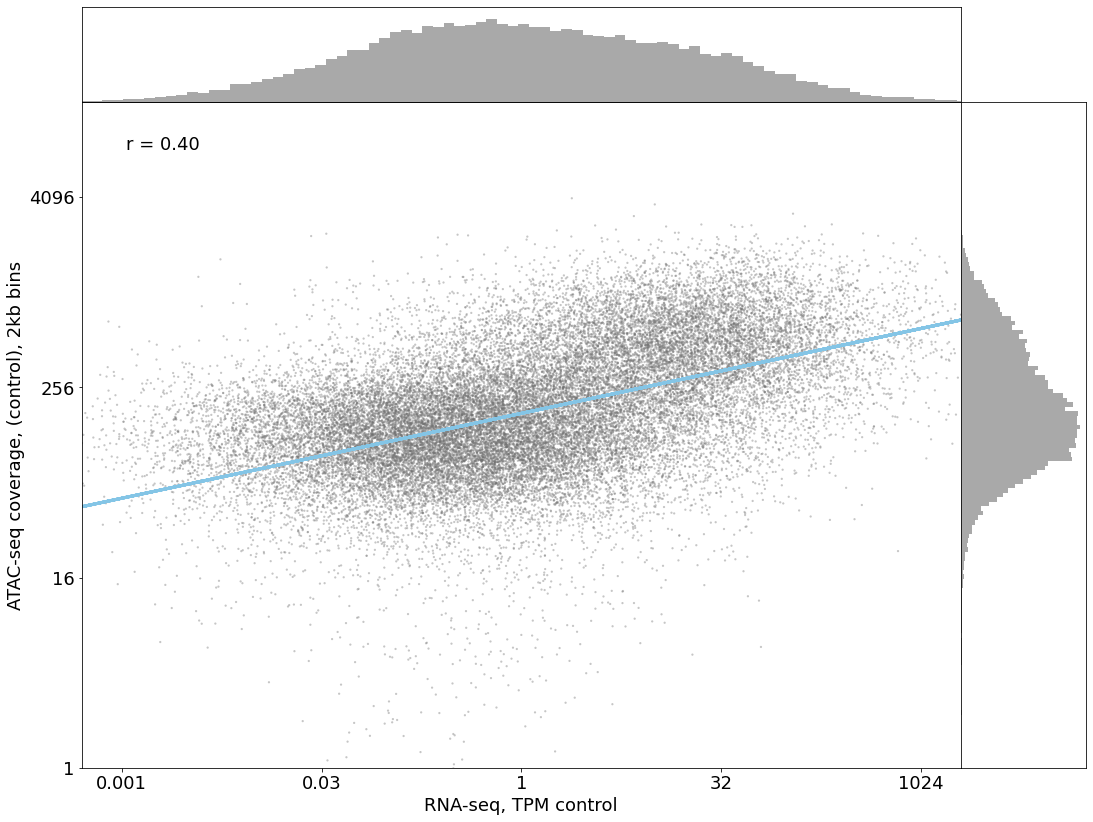

In [48]:
# RNA_seq control vs ATAC_seq control
# log2(data)

fig = plt.figure(figsize=[18, 14])
gs = GridSpec(8, 8, figure=fig)

# Main scatter plot
ax_main = fig.add_subplot(gs[1:8, 0:7])
ax_main.scatter(np.log2(RNA_seq_annot_for_bbi['tpm_ctr']),
                np.log2(RNA_seq_annot_for_bbi['ATAC_control']),
                s=5, alpha=0.4, color='#717171', edgecolors='none', linewidths=0, zorder=-1, rasterized=False)
ax_main.set_xlim([-11, 11])
ax_main.set_ylim([0, 14])
ax_main.set_xlabel('RNA-seq, TPM control', fontsize=18)
ax_main.set_ylabel('ATAC-seq coverage, (control), 2kb bins', fontsize=18)
ax_main.tick_params(axis='both', labelsize=18)

# Custom ticks and labels for X axis
custom_x_ticks = [-10, -5, 0, 5, 10]                  # positions in log2 space
custom_x_labels = ['0.001', '0.03', '1', '32', '1024'] # chosen labels
ax_main.set_xticks(custom_x_ticks)
ax_main.set_xticklabels(custom_x_labels, fontsize=18)

# Custom ticks and labels for Y axis
custom_y_ticks = [0, 4, 8, 12]                        # positions in log2 space
custom_y_labels = ['1', '16', '256', '4096']         # chosen labels
ax_main.set_yticks(custom_y_ticks)
ax_main.set_yticklabels(custom_y_labels, fontsize=18)

# Histogram along x-axis (top)
ax_x_hist = fig.add_subplot(gs[0, 0:7], sharex=ax_main)
ax_x_hist.hist(np.log2(RNA_seq_annot_for_bbi['tpm_ctr']),
               bins=100, color='#717171', alpha=0.6)
ax_x_hist.set_ylabel('')
ax_x_hist.set_xlabel('')
ax_x_hist.xaxis.set_visible(False)
ax_x_hist.yaxis.set_ticks([])
ax_x_hist.set_ylim([0, 1000])

# Histogram along y-axis (right)
ax_y_hist = fig.add_subplot(gs[1:8, 7], sharey=ax_main)
ax_y_hist.hist(np.log2(RNA_seq_annot_for_bbi['ATAC_control']),
               bins=300, orientation='horizontal', color='#717171', alpha=0.6)
ax_y_hist.set_ylabel('')
ax_y_hist.set_xlabel('')
ax_y_hist.yaxis.set_visible(False)
ax_y_hist.xaxis.set_ticks([])

# Compute correlation
x = np.log2(RNA_seq_annot_for_bbi['tpm_ctr'])
y = np.log2(RNA_seq_annot_for_bbi['ATAC_control'])
correlation_coefficient = np.corrcoef(x, y)[0, 1]

# Fit linear regression
m, b = np.polyfit(x, y, 1)
ax_main.plot(x, m*x + b, color='#84C5E6', linewidth=3)

# annotation to the main plot (top left corner)
ax_main.text(
    0.05, 0.95,  # X, Y position in axes fraction (0–1)
    f"r = {correlation_coefficient:.2f}",
    transform=ax_main.transAxes,
    fontsize=18,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=3)
)

# Adjust layout spacing
plt.subplots_adjust(hspace=0, wspace=0)

# plt.savefig(
#     "RNA_ctr_ATAC_ctr_log2space_raw_values_grey.pdf",
#     dpi=300,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )


In [37]:
print(f"Correlation coefficient (r): {correlation_coefficient}")

Correlation coefficient (r): 0.40398080617431925


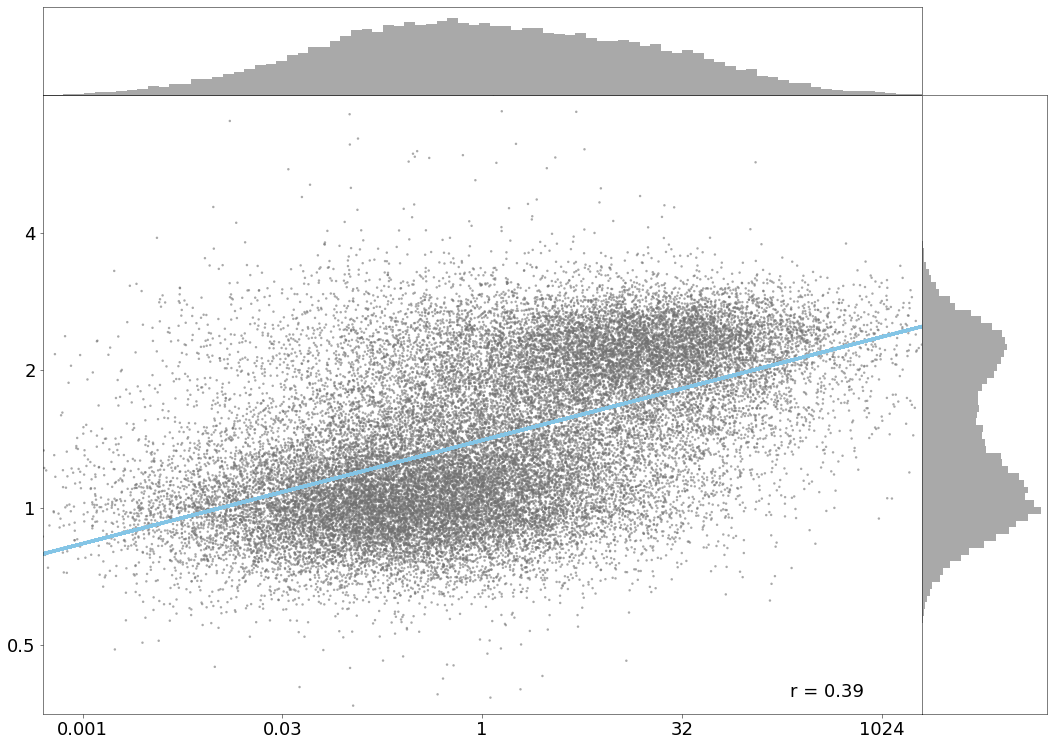

In [38]:
# RNA_seq control vs ATAC_seq change (CHd1 cKO/Control)
# log2(data)

fig = plt.figure(figsize=[18, 13])
gs = GridSpec(8, 8, figure=fig)

# Main scatter plot
ax_main = fig.add_subplot(gs[1:8, 0:7])

# rasterize everything below zorder 0 into one image
ax_main.set_rasterization_zorder(0)

# Scatter plot with color highlighting
ax_main.scatter(
    np.log2(RNA_seq_annot_for_bbi['tpm_ctr']),
    np.log2(RNA_seq_annot_for_bbi['ATAC_change']),
    s=6,
    alpha=0.6,
    c='#717171',
    edgecolors='none',
    linewidths=0,
    zorder=-1,
    rasterized=False  # zorder handles rasterization
)

ax_main.set_xlim([-11, 11])
ax_main.set_ylim([-1.5, 3])
ax_main.tick_params(axis='both', labelsize=18)

# Custom ticks and labels for X axis
custom_x_ticks = [-10, -5, 0, 5, 10]                  # positions in log2 space
custom_x_labels = ['0.001', '0.03', '1', '32', '1024'] # chosen labels
ax_main.set_xticks(custom_x_ticks)
ax_main.set_xticklabels(custom_x_labels, fontsize=18)

# Custom ticks and labels for Y axis
custom_y_ticks = [-1, 0, 1, 2]                        # positions in log2 space
custom_y_labels = ['0.5', '1', '2', '4']         # chosen labels
ax_main.set_yticks(custom_y_ticks)
ax_main.set_yticklabels(custom_y_labels, fontsize=18)

# Histogram along x-axis (top)
ax_x_hist = fig.add_subplot(gs[0, 0:7], sharex=ax_main)
ax_x_hist.hist(np.log2(RNA_seq_annot_for_bbi['tpm_ctr']),
               bins=100, color='#717171', alpha=0.6)
ax_x_hist.set_ylabel('')
ax_x_hist.set_xlabel('')
ax_x_hist.xaxis.set_visible(False)
ax_x_hist.yaxis.set_ticks([])
ax_x_hist.set_ylim([0, 1000])

# Histogram along y-axis (right)
ax_y_hist = fig.add_subplot(gs[1:8, 7], sharey=ax_main)
ax_y_hist.hist(np.log2(RNA_seq_annot_for_bbi['ATAC_change']),
               bins=800, orientation='horizontal', color='#717171', alpha=0.6)
ax_y_hist.set_ylabel('')
ax_y_hist.set_xlabel('')
ax_y_hist.yaxis.set_visible(False)
ax_y_hist.xaxis.set_ticks([])

# Compute correlation
x = np.log2(RNA_seq_annot_for_bbi['tpm_ctr'])
y = np.log2(RNA_seq_annot_for_bbi['ATAC_change'])
correlation_coefficient = np.corrcoef(x, y)[0, 1]

# Fit linear regression
m, b = np.polyfit(x, y, 1)
ax_main.plot(x, m*x + b, color='#84C5E6', linewidth=3)

# annotation to the main plot (top left corner, adjust position if needed)
ax_main.text(
    0.85, 0.05,  # X, Y position in axes fraction (0–1)
    f"r = {correlation_coefficient:.2f}",
    transform=ax_main.transAxes, 
    fontsize=18,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=3) 
)

for ax in [ax_main, ax_x_hist, ax_y_hist]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)  

# Adjust layout spacing
plt.subplots_adjust(hspace=0, wspace=0)

plt.show()

# plt.savefig(
#     "RNA_ctr_ATAC_change_log2space_raw_values_C3.pdf",
#     dpi=600,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )

In [ ]:
correlation_coefficient

0.39405189496781373

In [41]:

DeSeq2_FDR001 = pd.read_csv("/users/uladzis.khauratovich/groups_SLAVA/RNA_seq_CHD1/Claudia_deseq2_featureCounts_resultTables/DESeq2_1.18.1.Experimental_VS_Control.alpha01.tsv", sep="\t")
RNA_seq_annot_for_bbi = pd.merge(RNA_seq_annot_for_bbi, DeSeq2_FDR001[['gene_id', 'sign']], on='gene_id', how='left')

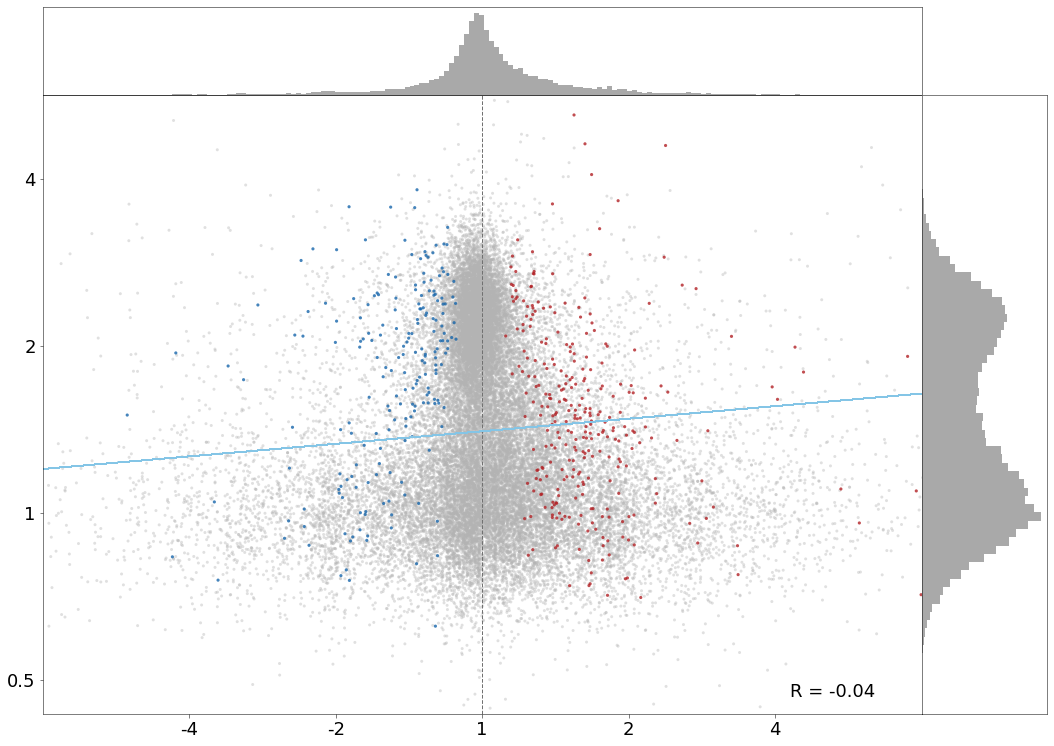

In [42]:
# RNA_seq change (CHD1 cKO/Control) vs ATAC_seq change (CHD1 cKO/Control)
# log2(data)

fig = plt.figure(figsize=[18, 13])
gs = GridSpec(8, 8, figure=fig)

# Main scatter plot
ax_main = fig.add_subplot(gs[1:8, 0:7])

neutral_df = RNA_seq_annot_for_bbi[RNA_seq_annot_for_bbi['sign'] == '-']
up_df = RNA_seq_annot_for_bbi[RNA_seq_annot_for_bbi['sign'] == 'up']
down_df = RNA_seq_annot_for_bbi[RNA_seq_annot_for_bbi['sign'] == 'down']

# 1. Plot all points in grey
ax_main.scatter(
    np.log2(neutral_df['RNA_change']),
    np.log2(neutral_df['ATAC_change']),
    s=9,
    alpha=0.4,
    color='#b3b3b3',  # light grey
    edgecolors='none',
    linewidths=0,
    zorder=-2,
    rasterized=False
)

# 2. Plot 'up' points in red
ax_main.scatter(
    np.log2(up_df['RNA_change']),
    np.log2(up_df['ATAC_change']),
    s=10,
    alpha=0.8,
    color='#B22125',
    edgecolors='none',
    linewidths=0,
    zorder=-1
)

# 3. Plot 'down' points in blue
ax_main.scatter(
    np.log2(down_df['RNA_change']),
    np.log2(down_df['ATAC_change']),
    s=10,
    alpha=0.8,
    color='#1766ab',
    edgecolors='none',
    linewidths=0,
    zorder=-1
)

ax_main.set_xlim([-3, 3])
ax_main.set_ylim([-1.2, 2.5])
ax_main.tick_params(axis='both', labelsize=18)

# Custom ticks and labels for X axis
custom_x_ticks = [-2, -1, 0, 1, 2]                  # positions in log2 space
custom_x_labels = ['-4', '-2', '1', '2', '4',] # chosen labels
ax_main.set_xticks(custom_x_ticks)
ax_main.set_xticklabels(custom_x_labels, fontsize=18)

# Custom ticks and labels for Y axis
custom_y_ticks = [-1, 0, 1, 2]                        # positions in log2 space
custom_y_labels = ['0.5', '1', '2', '4']         # chosen labels
ax_main.set_yticks(custom_y_ticks)
ax_main.set_yticklabels(custom_y_labels, fontsize=18)


for xpos in [np.log2(100), np.log2(0.0001), np.log2(0.01), np.log2(1)]:
    ax_main.axvline(x=xpos, color='#717171', linestyle="dashed", linewidth=1)

# Histogram along x-axis (top)
ax_x_hist = fig.add_subplot(gs[0, 0:7], sharex=ax_main)
ax_x_hist.hist(np.log2(RNA_seq_annot_for_bbi['RNA_change']),
               bins=380, color='#717171', alpha=0.6)
ax_x_hist.set_ylabel('')
ax_x_hist.set_xlabel('')
ax_x_hist.xaxis.set_visible(False)
ax_x_hist.yaxis.set_ticks([])
ax_x_hist.set_ylim([0, 2200])

# Histogram along y-axis (right)
ax_y_hist = fig.add_subplot(gs[1:8, 7], sharey=ax_main)
ax_y_hist.hist(np.log2(RNA_seq_annot_for_bbi['ATAC_change']),
               bins=800, orientation='horizontal', color='#717171', alpha=0.6)
ax_y_hist.set_ylabel('')
ax_y_hist.set_xlabel('')
ax_y_hist.yaxis.set_visible(False)
ax_y_hist.xaxis.set_ticks([])

# Fit linear regression
m, b = np.polyfit(x, y, 1)
ax_main.plot(x, m*x + b, color='#84C5E6', linewidth=1)

# Compute correlation
x = np.log2(RNA_seq_annot_for_bbi['RNA_change'])
y = np.log2(RNA_seq_annot_for_bbi['ATAC_change'])
correlation_coefficient = np.corrcoef(x, y)[0, 1]

# Add annotation to the main plot (top left corner, adjust position if needed)
ax_main.text(
    0.85, 0.05,  # X, Y position in axes fraction (0–1)
    f"R = {correlation_coefficient:.2f}",
    transform=ax_main.transAxes,  
    fontsize=18,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=3) 
)

for ax in [ax_main, ax_x_hist, ax_y_hist]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

# Adjust layout spacing
plt.subplots_adjust(hspace=0, wspace=0)

plt.show()
# plt.savefig(
#     "RNA_change_ATAC_change_log2space_highlited_dots_gray_bigger_dots_light_gray.pdf",
#     dpi=600,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )


In [43]:
correlation_coefficient

-0.040103824375955534